# 3D Metrics

To assess segmentation performance in 3D, we can use metrics from the `vl` (volume) accessor.

**NOTE:** This module is still experimental and will change substantially in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

## Correlations between the top and bottom of the slice

To assess if there are cells lying on top of each other in the z plane, we can slice our data into a top and bottom plane, e. g. by taking the top 25% and the bottom 25%. We can then compute the Pearson correlation between the two planes for each cell. If the correlation is high, the top and bottom layers likely show the same cell. If it is low, there might be two or more cells overlapping in the z direction.

In [1]:
%load_ext autoreload
%autoreload 2

import copy

import matplotlib.pyplot as plt
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

st = segtraq.SegTraQ(
    sd.read_zarr("../../data/proseg2.zarr"),
    images_key="image",
    labels_to_cell_id_key="label_id",
    points_background_id=0,
    tables_area_volume_key="volume",
)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: Fut

In [2]:
correlation_df = st.vl.compute_z_plane_correlation()
# removing the unassigned transcripts
correlation_df = correlation_df[correlation_df.index != 0]
correlation_df.head()

,correlation
cell_id,
1,0.360827
2,-0.001534
3,-0.000375
4,0.046278
5,0.110641


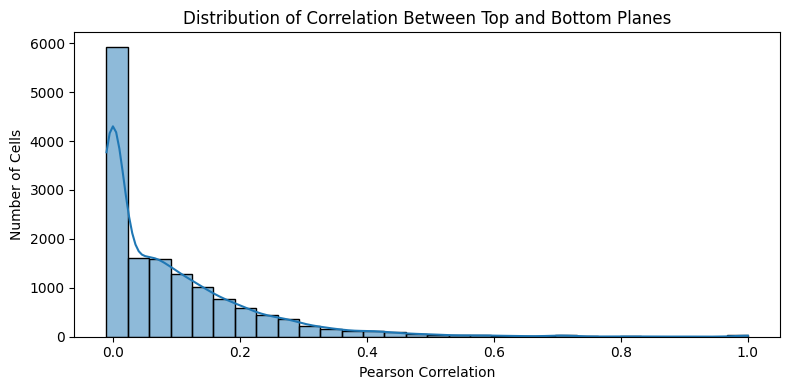

In [3]:
# Plot the distribution of correlation values
plt.figure(figsize=(8, 4))
sns.histplot(correlation_df["correlation"], bins=30, kde=True)

plt.title("Distribution of Correlation Between Top and Bottom Planes")
plt.xlabel("Pearson Correlation")
plt.ylabel("Number of Cells")
plt.tight_layout()
plt.show()

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries_z0` already exists. Overwriting it in-memory.
  s

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries_z3` already exists. Overwriting it in-memory.
  s

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


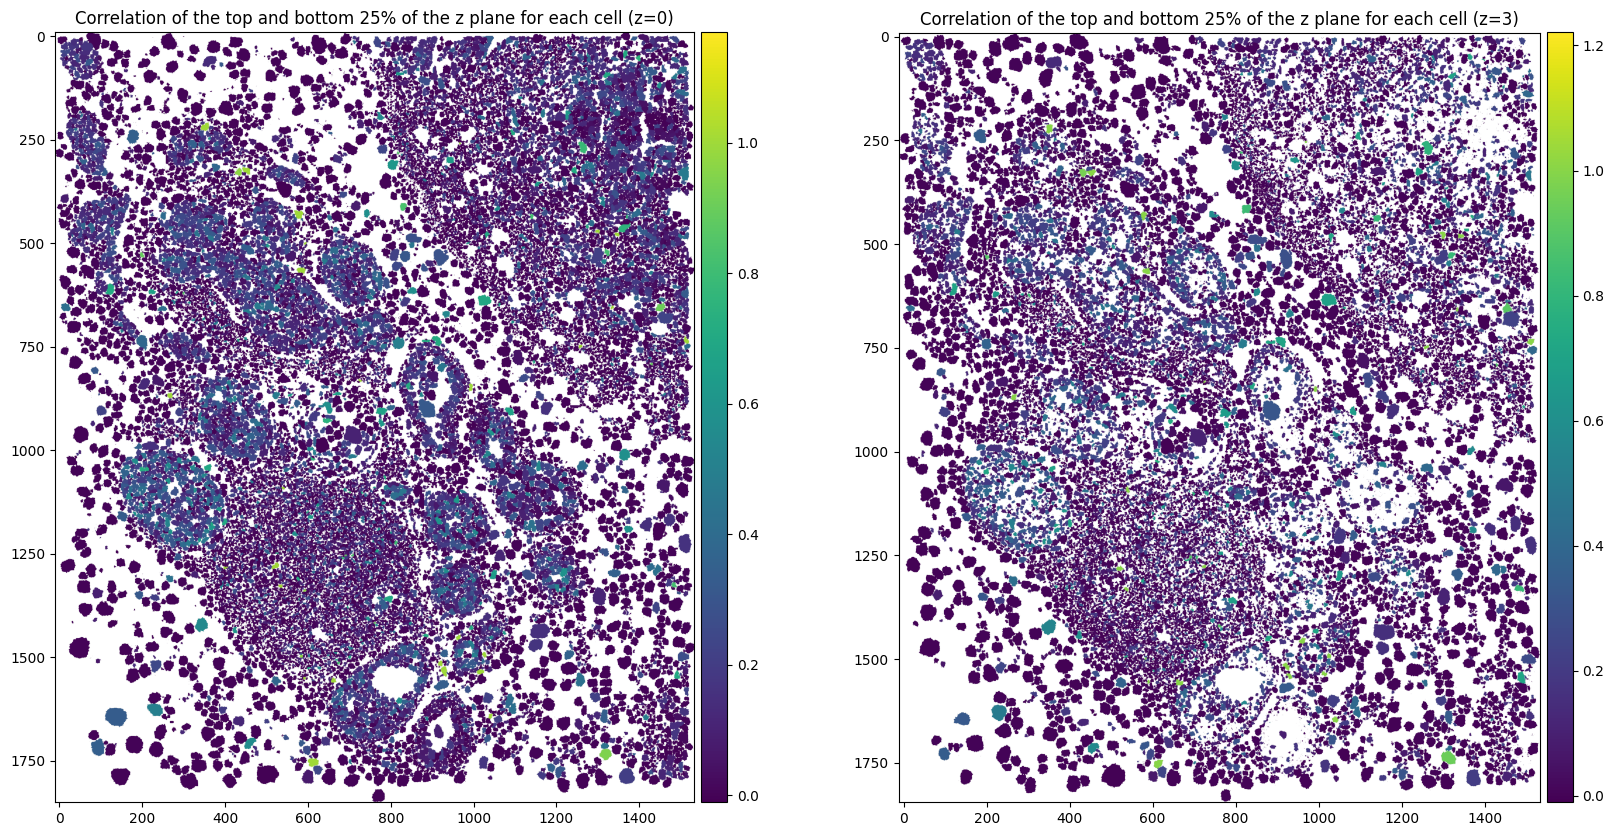

In [4]:
# plotting the correlation on the bottom and top plane respectively
fix, ax = plt.subplots(1, 2, figsize=(20, 10))

sdata_plot = copy.deepcopy(st.sdata)
sdata_plot.tables["table"].obs["region"] = "cell_boundaries_z0"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries_z0")
sdata_plot.pl.render_shapes("cell_boundaries_z0", color="correlation").pl.show(
    title="Correlation of the top and bottom 25% of the z plane for each cell (z=0)",
    coordinate_systems="global",
    ax=ax[0],
)

sdata_plot = copy.deepcopy(st.sdata)
sdata_plot.tables["table"].obs["region"] = "cell_boundaries_z3"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries_z3")
sdata_plot.pl.render_shapes("cell_boundaries_z3", color="correlation").pl.show(
    title="Correlation of the top and bottom 25% of the z plane for each cell (z=3)",
    coordinate_systems="global",
    ax=ax[1],
)

You can run all functions in the `vl` module using `run_volume()`.

In [5]:
st.run_volume()
st.sdata.tables["table"].obs

,cell_id,centroid_x,centroid_y,centroid_z,volume,label_id,region,correlation
0,1,154.66340,1053.593600,-0.115346,1131.674000,1,cell_labels,0.360827
1,2,348.67285,287.598750,0.524985,256.049380,2,cell_labels,-0.001534
2,3,720.20215,1218.872300,0.660745,148.571900,3,cell_labels,-0.000375
3,4,877.44590,1707.412100,-0.980020,233.921080,4,cell_labels,0.046278
4,5,1253.77540,1426.495100,0.859675,327.174870,5,cell_labels,0.110641
...,...,...,...,...,...,...,...,...
17880,17881,1027.99170,123.166664,-1.144839,189.666200,17881,cell_labels,0.000000
17881,17882,1422.56730,47.375000,0.382015,164.377410,17882,cell_labels,0.100298
17882,17883,578.78050,966.006100,0.165542,259.210450,17883,cell_labels,0.203358
17883,17884,207.73756,364.975130,0.303928,286.080100,17884,cell_labels,-0.002220
